# PyTorch 与神经网络模型实践

## 1. PyTorch 基础

### 1.1 张量运算

**请使用 PyTorch 内置函数完成，避免显式循环。**

1. 创建一个形状为 (6, 5) 的随机整数张量 `A`，取值范围为 {0, 1, ..., 10}。打印出该张量；
2. 将 `A` 的每一行减去该行的均值（行中心化），得到张量 `A_centered`，使用广播实现。打印出该张量；
3. 打印出 `A_centered` 的行和向量以及列和向量。

In [1]:
import torch

torch.manual_seed(42)

A = torch.randint(0, 11, (6, 5)).float()
print("张量 A：")
print(A)

# 行中心化
row_mean = A.mean(dim=1, keepdim=True)
A_centered = A - row_mean
print("\n行中心化后的 A_centered：")
print(A_centered)

row_sum = A_centered.sum(dim=1)
print("\n行和向量：")
print(row_sum)

col_sum = A_centered.sum(dim=0)
print("\n列和向量：")
print(col_sum)

张量 A：
tensor([[ 6.,  7.,  9.,  3.,  2.],
        [10.,  3.,  0.,  8.,  2.],
        [ 1., 10.,  3.,  4.,  2.],
        [ 0.,  4.,  3.,  6.,  9.],
        [10.,  8.,  9.,  6.,  3.],
        [ 0.,  1., 10.,  3.,  4.]])

行中心化后的 A_centered：
tensor([[ 0.6000,  1.6000,  3.6000, -2.4000, -3.4000],
        [ 5.4000, -1.6000, -4.6000,  3.4000, -2.6000],
        [-3.0000,  6.0000, -1.0000,  0.0000, -2.0000],
        [-4.4000, -0.4000, -1.4000,  1.6000,  4.6000],
        [ 2.8000,  0.8000,  1.8000, -1.2000, -4.2000],
        [-3.6000, -2.6000,  6.4000, -0.6000,  0.4000]])

行和向量：
tensor([-4.7684e-07,  4.7684e-07,  0.0000e+00, -4.7684e-07,  9.5367e-07,
         4.7684e-07])

列和向量：
tensor([-2.2000,  3.8000,  4.8000,  0.8000, -7.2000])


以下每一步都需打印出操作的结果。

1. 创建一个形状为 (8, 8) 的随机正态分布张量 `X`（均值为 0.5，方差为2）；
2. 提取 `X` 中所有大于1.5的元素，构成一维张量；
3. 将 `X` 中绝对值小于0.5的元素替换为0，结果保存为张量 `X_masked`；
4. 取出 `X` 的第2行、第4列的元素；
5. 取出 `X` 的第3-6行、第2-5列构成的子矩阵。

In [2]:
torch.manual_seed(42)

X = torch.normal(mean=0.5, std=2.0 ** 0.5, size=(8, 8))
print("张量 X：")
print(X)

large_elements = X[X > 1.5]
print(f"\n所有大于 1.5 的元素（共 {len(large_elements)} 个）：")
print(large_elements)

X_masked = X.clone()
X_masked[X_masked.abs() < 0.5] = 0
print("\nX_masked：")
print(X_masked)

elem = X[1, 3]
print(f"\nX 的第 2 行、第 4 列的元素：{elem.item():.4f}")

submatrix = X[2:6, 1:5]
print("\nX 的第 3~6 行、第 2~5 列子矩阵：")
print(submatrix)

张量 X：
tensor([[ 3.2251,  2.6033,  1.7738, -2.4777,  1.4594, -1.2459,  0.4391, -1.7693],
        [-0.5637,  2.8316, -0.0550, -1.4850, -0.5294, -0.2912, -0.5873,  1.5783],
        [ 2.8226,  0.2743, -0.2034,  1.1217, -0.5722,  2.0250,  1.6325,  2.8768],
        [ 2.3090,  2.3334,  1.3633,  2.3876,  0.1724,  0.5591,  0.1442,  1.7160],
        [-1.4582, -0.7321,  0.1841,  2.9287,  0.9510, -0.1004,  0.9324, -0.5954],
        [-1.7027,  1.9080, -0.7442, -0.3501, -1.3019,  3.5021, -1.2461, -0.1900],
        [-0.7923, -0.4307,  0.6103,  1.2436, -0.1901,  2.1849, -0.6512, -0.5409],
        [-1.4845,  0.5509,  0.4102,  1.4555,  0.3617,  3.1086, -1.1752,  2.4566]])

所有大于 1.5 的元素（共 19 个）：
tensor([3.2251, 2.6033, 1.7738, 2.8316, 1.5783, 2.8226, 2.0250, 1.6325, 2.8768,
        2.3090, 2.3334, 2.3876, 1.7160, 2.9287, 1.9080, 3.5021, 2.1849, 3.1086,
        2.4566])

X_masked：
tensor([[ 3.2251,  2.6033,  1.7738, -2.4777,  1.4594, -1.2459,  0.0000, -1.7693],
        [-0.5637,  2.8316,  0.0000, -1.4850,

### 1.2 常见函数与自动微分

多分类问题的数据通常包括数据阵 $X$ 和标签向量 $l$，其中标签为整数。在计算损失函数时，我们需要先将 $l$ 转换成多项分布的0-1数据，即所谓 One-hot 编码。运行并观察下面的代码。

In [3]:
import numpy as np
import torch
import torch.nn as nn

np.random.seed(123456)
torch.manual_seed(123456)

n = 200  # 样本量
p = 10   # 变量数
k = 4    # 类别数
x = torch.randn(n, p)
l = torch.tensor(np.random.choice(range(4), size=n, replace=True), dtype=int)
print(l[:20])

y = torch.nn.functional.one_hot(l)
print(y.shape)
print(y[:10])

tensor([1, 2, 2, 1, 0, 3, 3, 3, 3, 0, 3, 0, 0, 2, 2, 0, 3, 0, 3, 3])
torch.Size([200, 4])
tensor([[0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 1, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1],
        [1, 0, 0, 0]])


请创建矩阵 `W`，大小为 $k \times p$，用 N(0, 2) 填充其取值。

In [4]:
W = torch.normal(mean=0.0, std=2.0 ** 0.5, size=(k, p)).requires_grad_(True)
print("W 形状：", W.shape)
print("W：\n", W)

W 形状： torch.Size([4, 10])
W：
 tensor([[ 1.2777, -0.1788, -4.2187, -2.7614, -0.3042,  1.2681,  0.3002, -1.9368,
         -0.7806,  1.8369],
        [ 0.0210,  2.6174, -0.4458, -1.9419,  0.9540, -0.0048, -0.8711,  0.2246,
          0.1156, -0.7405],
        [-1.8104,  0.7303,  0.3747, -0.1705, -1.0532,  0.9106, -1.5661, -1.2486,
         -1.4339,  2.0920],
        [ 0.9660, -1.1287, -0.0369, -0.6253, -0.7704, -0.2679, -0.1700, -1.9835,
         -1.3863,  2.1378]], requires_grad=True)


接下来计算对 $Y$ 的概率预测值，其中每个 $Y_i$ 观测对应一个等长的概率向量 $p_i$，而 $p_i=\mathrm{Softmax}(Wx_i)$。首先计算 $Wx_i$，其中 $x_i$ 是第 $i$ 个观测。由于 $X$ 是把 $x_i$ 按行组合，因此矩阵形式表达为 $U=XW'$，其中 $U$ 的第 $i$ 行即为 $Wx_i$。

In [5]:
U = x @ W.t()
print("U 形状：", U.shape)
print("U 前 5 行：\n", U[:5])

U 形状： torch.Size([200, 4])
U 前 5 行：
 tensor([[ -9.0260, -11.9811,   1.2114,  -0.4195],
        [  3.4307,  -0.7834,  -3.4165,  -0.6344],
        [ -1.8140,   6.9210,  -3.2333,  -3.6561],
        [  9.2793,  -2.4792,  -0.8735,   2.2520],
        [ -4.1917,  -0.2071,  -1.5019,   0.3890]], grad_fn=<SliceBackward0>)


我们先测试一下 $\mathrm{Softmax}(Wx_{100})$ 的结果，观察其元素和是否为1。代码中的 `dim=0` 意思是对第一个下标方向计算 Softmax，由于 `U[99]` 是一个向量，因此第一个下标方向就是该向量本身。

In [6]:
torch.softmax(U[99], dim=0)

tensor([0.1481, 0.0201, 0.7261, 0.1056], grad_fn=<SoftmaxBackward0>)

而为了对 $U$ 的每一行都计算 Softmax，我们可以直接对整个 `U` 矩阵用 `torch.softmax`，其中 `dim` 需指定为1，意思是对第二个下标方向求 Softmax，即对 $U$ 的每一行。原理类似于按坐标轴汇总。请完成该计算，得到矩阵 $P$，其中 $P$ 的第 $i$ 行即为 $p_i$。

In [7]:
P = torch.softmax(U, dim=1)
print("P 形状：", P.shape)
print("各行之和：", P.sum(dim=1)[:5])
print("P 前 5 行：\n", P[:5])

P 形状： torch.Size([200, 4])
各行之和： tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SliceBackward0>)
P 前 5 行：
 tensor([[2.9942e-05, 1.5592e-06, 8.3627e-01, 1.6369e-01],
        [9.6805e-01, 1.4313e-02, 1.0284e-03, 1.6613e-02],
        [1.6082e-04, 9.9977e-01, 3.8901e-05, 2.5487e-05],
        [9.9907e-01, 7.8152e-06, 3.8930e-05, 8.8653e-04],
        [5.9852e-03, 3.2181e-01, 8.8154e-02, 5.8406e-01]],
       grad_fn=<SliceBackward0>)


根据 `y` 和 `P` 两个矩阵，即可根据公式得到对数似然函数值。总结上述步骤，编写损失函数 `loss_fn_softmax(w, x, y)`，返回**负**对数似然值。

In [8]:
def loss_fn_softmax(w, x, y):
    scores = x @ w.t()
    prob = torch.softmax(scores, dim=1)
    log_prob = torch.log(prob + 1e-10)
    nll = -(y.float() * log_prob).sum() / y.shape[0]
    return nll

Pytorch 中也提供了 CrossEntropyLoss 损失函数，参见[其文档](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)。其用法是先建立一个损失函数对象，然后将 $U$ 和 $l$ 作为参数传入（注意 $U$ 是经过 Softmax **之前**的矩阵，$l$ 是**原始**的标签）。请利用这种方法计算损失函数值，并与你自己的函数结果进行对比。

In [9]:
ce_softmax = nn.CrossEntropyLoss()
loss1 = ce_softmax(U, l)

loss2 = loss_fn_softmax(W, x, y)

print(loss1)
print(loss2)

tensor(4.4628, grad_fn=<NllLossBackward0>)
tensor(4.4627, grad_fn=<DivBackward0>)


利用 PyTorch 的自动微分功能，计算上述损失函数在 $W=O$ 处的梯度，其中 $O$ 是一个元素全为0的矩阵。

In [10]:
W_zero = torch.zeros(k, p, requires_grad=True)

loss_at_zero = loss_fn_softmax(W_zero, x, y)
print(f"W=O 处的损失值：{loss_at_zero.item():.6f}")

loss_at_zero.backward()

print("\n损失函数在 W=O 处的梯度：")
print(W_zero.grad)

W=O 处的损失值：1.386294

损失函数在 W=O 处的梯度：
tensor([[-0.0198,  0.0474,  0.0067, -0.0427, -0.0012, -0.0092,  0.0167,  0.0030,
          0.0800, -0.0152],
        [ 0.0250, -0.0273, -0.0283,  0.0377,  0.0333, -0.0031,  0.0130,  0.0072,
         -0.0125,  0.0173],
        [-0.0236, -0.0355,  0.0060,  0.0342, -0.0175,  0.0324, -0.0054,  0.0260,
          0.0312, -0.0129],
        [ 0.0183,  0.0154,  0.0155, -0.0292, -0.0146, -0.0201, -0.0243, -0.0363,
         -0.0988,  0.0108]])


## 2. 前馈神经网络

### 2.1 线性模型

利用模块化编程（参考课件 `lec6-module.ipynb` 中的实现），在如下模拟数据上构建一个 Logistic 回归模型（包含截距项），并利用自动微分和优化器求解回归系数。要求使用 PyTorch 中的 `nn.Linear` 模块完成模型构建。

In [11]:
import numpy as np

def gen_data(n_obs=1000, radius=1.0, eye_oversample_ratio=0.0):
    factor = 1.5
    n_candidates = int(n_obs * factor)
    points = np.random.uniform(-radius, radius, size=(n_candidates, 2))

    r_sq = np.sum(points**2, axis=1)
    inside = (r_sq <= radius**2)
    points = points[inside]

    while len(points) < n_obs:
        extra = np.random.uniform(-radius, radius, size=(n_obs, 2))
        inside_extra = (np.sum(extra**2, axis=1) <= radius**2)
        extra = extra[inside_extra]
        points = np.vstack([points, extra])
    points = points[:n_obs]

    x1, x2 = points[:, 0], points[:, 1]
    half_r = radius / 2.0
    eye_r = radius / 5.0

    upper_semi = (x1 > 0) & ((x1**2 + (x2 - half_r)**2) <= half_r**2)
    lower_semi = (x1 < 0) & ((x1**2 + (x2 + half_r)**2) <= half_r**2)

    yang_eye = (x1**2 + (x2 - half_r)**2) <= eye_r**2
    yin_eye = (x1**2 + (x2 + half_r)**2) <= eye_r**2

    labels = np.full(len(points), -1, dtype=int)
    labels[upper_semi] = 0
    labels[yang_eye] = 1
    labels[lower_semi] = 1
    labels[yin_eye] = 0

    rest = (labels == -1)
    labels[rest & (x1 >= 0)] = 1
    labels[rest & (x1 < 0)] = 0

    if eye_oversample_ratio > 0:
        n_extra = int(n_obs * eye_oversample_ratio)

        def sample_disk(center, radius_disk, n):
            pts = np.random.uniform(-radius_disk, radius_disk, size=(int(n * 1.5), 2))
            inside_d = np.sum(pts**2, axis=1) <= radius_disk**2
            pts = pts[inside_d][:n]
            while len(pts) < n:
                extra_pts = np.random.uniform(-radius_disk, radius_disk, size=(n, 2))
                in_extra = np.sum(extra_pts**2, axis=1) <= radius_disk**2
                extra_pts = extra_pts[in_extra]
                pts = np.vstack([pts, extra_pts])[:n]
            return pts + np.array(center)

        extra_yang_pts = sample_disk(center=(0, half_r), radius_disk=eye_r, n=n_extra)
        extra_yang_labels = np.ones(n_extra, dtype=int)

        extra_yin_pts = sample_disk(center=(0, -half_r), radius_disk=eye_r, n=n_extra)
        extra_yin_labels = np.zeros(n_extra, dtype=int)

        points = np.vstack([points, extra_yang_pts, extra_yin_pts])
        labels = np.concatenate([labels, extra_yang_labels, extra_yin_labels])

    return points, labels

np.random.seed(123456)
x, y = gen_data(n_obs=1000, radius=10.0, eye_oversample_ratio=0.1)
print(x[:5])
print(y[:5])

[[-4.79047988  7.94473049]
 [-2.46500568 -3.27556511]
 [-0.97247059  6.80510167]
 [-7.53795711  0.86052404]
 [-2.5397555  -1.04006351]]
[0 1 0 0 1]


数据散点图：

<Axes: xlabel='x1', ylabel='x2'>

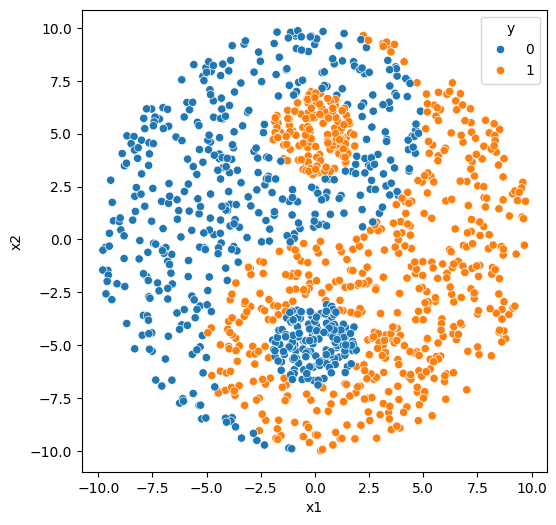

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dat = pd.DataFrame(x, columns=["x1", "x2"])
dat["y"] = y
plt.figure(figsize=(6, 6))
sns.scatterplot(data=dat, x="x1", y="x2", hue="y")

请在下方完成训练代码：

In [13]:
import torch
import torch.nn as nn
import numpy as np

torch.manual_seed(42)

X_train = torch.tensor(x, dtype=torch.float32)
y_train = torch.tensor(y, dtype=torch.float32)

class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x)).squeeze(1)

model_lr = LogisticRegression(input_dim=2)
optimizer_lr = torch.optim.Adam(model_lr.parameters(), lr=0.01)

n_epochs_lr = 500
losses_lr = []

for epoch in range(n_epochs_lr):
    model_lr.train()
    pred = model_lr(X_train)
    loss = -torch.mean(
        y_train * torch.log(pred + 1e-10) +
        (1 - y_train) * torch.log(1 - pred + 1e-10)
    )
    optimizer_lr.zero_grad()
    loss.backward()
    optimizer_lr.step()
    losses_lr.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{n_epochs_lr}，Loss = {loss.item():.4f}")

print("\nLogistic 回归训练完成！")

Epoch 100/500，Loss = 0.5007
Epoch 200/500，Loss = 0.5006
Epoch 300/500，Loss = 0.5006
Epoch 400/500，Loss = 0.5006
Epoch 500/500，Loss = 0.5006

Logistic 回归训练完成！


完成模型训练后，利用得到的模型对如下测试集数据进行预测（概率 >0.5 判为1，反之判为0），计算分类的正确率。

In [14]:
np.random.seed(654321)
xtest, ytest = gen_data(n_obs=200, radius=10.0, eye_oversample_ratio=0.1)

In [15]:
X_test = torch.tensor(xtest, dtype=torch.float32)
y_test = torch.tensor(ytest, dtype=torch.float32)

model_lr.eval()
with torch.no_grad():
    pred_prob_lr = model_lr(X_test)
    pred_label_lr = (pred_prob_lr > 0.5).float()

accuracy_lr = (pred_label_lr == y_test).float().mean().item()
print(f"Logistic 回归测试集正确率：{accuracy_lr:.4f}（{accuracy_lr*100:.1f}%）")

Logistic 回归测试集正确率：0.6667（66.7%）


### 2.2 前馈神经网络

修改上面的线性模型，将其变为一个两层的前馈神经网络，隐藏神经元数量为32，使用 ReLU 激活函数。然后重新训练模型（可尝试使用不同的学习率和迭代次数），记录每次迭代的损失函数值并绘制损失函数值随迭代次数的曲线。最后对测试集进行预测，计算分类的正确率（目标是 >90%）。

Epoch 100/500，Loss = 0.3779
Epoch 200/500，Loss = 0.3036
Epoch 300/500，Loss = 0.2560
Epoch 400/500，Loss = 0.2087
Epoch 500/500，Loss = 0.1654


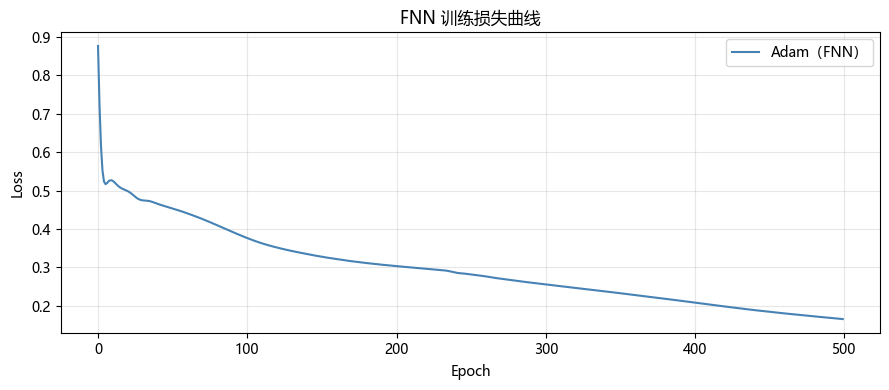


FNN 测试集正确率：0.8875（88.7%）


In [22]:
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False 
torch.manual_seed(42)

class FNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze(1)

model_fnn = FNN(input_dim=2, hidden_dim=32)
optimizer_fnn = torch.optim.Adam(model_fnn.parameters(), lr=0.01)

n_epochs_fnn = 500
losses_fnn = []

for epoch in range(n_epochs_fnn):
    model_fnn.train()
    pred = model_fnn(X_train)
    loss = -torch.mean(
        y_train * torch.log(pred + 1e-10) +
        (1 - y_train) * torch.log(1 - pred + 1e-10)
    )
    optimizer_fnn.zero_grad()
    loss.backward()
    optimizer_fnn.step()
    losses_fnn.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{n_epochs_fnn}，Loss = {loss.item():.4f}")

plt.figure(figsize=(9, 4))
plt.plot(losses_fnn, label="Adam（FNN）", color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FNN 训练损失曲线")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

model_fnn.eval()
with torch.no_grad():
    pred_prob_fnn = model_fnn(X_test)
    pred_label_fnn = (pred_prob_fnn > 0.5).float()

accuracy_fnn = (pred_label_fnn == y_test).float().mean().item()
print(f"\nFNN 测试集正确率：{accuracy_fnn:.4f}（{accuracy_fnn*100:.1f}%）")

### 2.3 Muon 优化器

请重新对上述前馈神经网络进行初始化和训练，但使用 Muon 优化器。**注意：Muon 只能对矩阵型参数进行优化，把向量型的参数传递给 Muon 会报错。**

请使用如下思路解决：构建两个优化器，Adam 和 Muon，将模型的参数分成两个列表，矩阵类的传递给 Muon，其他类的传递给 Adam，然后在训练循环中分别调用两个优化器的 `zero_grad()` 和 `step()` 函数。

请记录下这种方式下每次迭代的损失函数值，并与上一节中的曲线绘制在同一张图中进行对比。

Epoch 100/500，Loss = 0.4384
Epoch 200/500，Loss = 0.3429
Epoch 300/500，Loss = 0.2918
Epoch 400/500，Loss = 0.2509
Epoch 500/500，Loss = 0.2273


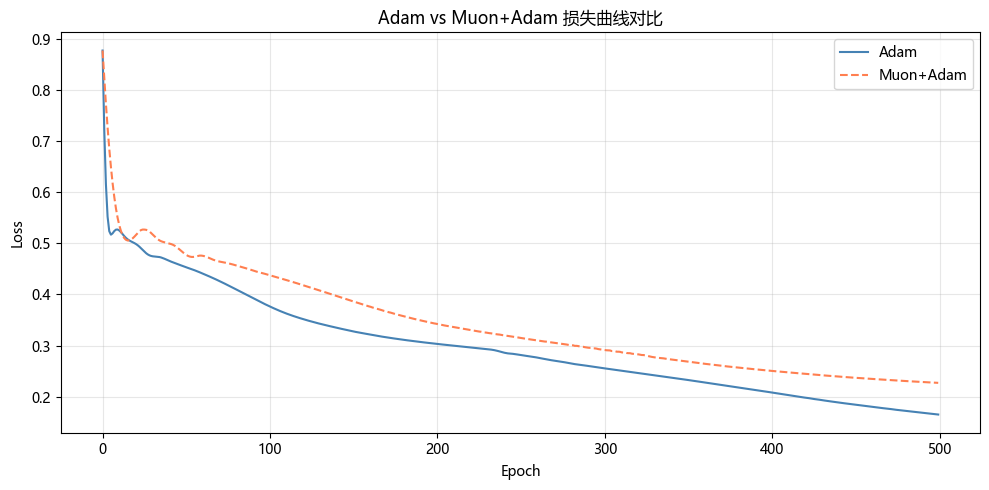

Muon+Adam 测试集正确率：0.8500（85.0%）
Adam      测试集正确率：0.8875（88.7%）


In [23]:
torch.manual_seed(42)

model_muon = FNN(input_dim=2, hidden_dim=32)

muon_params = [p for p in model_muon.parameters() if p.ndim >= 2]
adam_params  = [p for p in model_muon.parameters() if p.ndim < 2]

optimizer_muon_w = torch.optim.Muon(muon_params, lr=0.01, momentum=0.95)
optimizer_adam_b = torch.optim.Adam(adam_params, lr=0.01)

losses_muon = []

for epoch in range(n_epochs_fnn):
    model_muon.train()
    pred = model_muon(X_train)
    loss = -torch.mean(
        y_train * torch.log(pred + 1e-10) +
        (1 - y_train) * torch.log(1 - pred + 1e-10)
    )
    optimizer_muon_w.zero_grad()
    optimizer_adam_b.zero_grad()
    loss.backward()
    optimizer_muon_w.step()
    optimizer_adam_b.step()
    losses_muon.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{n_epochs_fnn}，Loss = {loss.item():.4f}")

plt.figure(figsize=(10, 5))
plt.plot(losses_fnn,  label="Adam",      color="steelblue")
plt.plot(losses_muon, label="Muon+Adam", color="coral", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adam vs Muon+Adam 损失曲线对比")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

model_muon.eval()
with torch.no_grad():
    pred_prob_muon  = model_muon(X_test)
    pred_label_muon = (pred_prob_muon > 0.5).float()

accuracy_muon = (pred_label_muon == y_test).float().mean().item()
print(f"Muon+Adam 测试集正确率：{accuracy_muon:.4f}（{accuracy_muon*100:.1f}%）")
print(f"Adam      测试集正确率：{accuracy_fnn:.4f}（{accuracy_fnn*100:.1f}%）")

## 3. 预训练模型实战

请学习语音识别模型 Whisper 的使用方法（访问 [https://hf-mirror.com/openai/whisper-small](https://hf-mirror.com/openai/whisper-small) 或 [https://huggingface.co/openai/whisper-small](https://huggingface.co/openai/whisper-small)），完成以下任务：

1. 准备一段文字（内容任意，朗读出来大约10秒钟），填写在下方的文本框里。
2. 朗读这段文字，利用录音软件录制一段10秒左右的音频，保存为 `.wav` 格式。
3. 根据网站上的文档学习使用 Whisper 预训练模型，将预训练模型下载到本地，并识别你录制的音频，将其转为文字，打印出来。
4. 配备有 Nvidia GPU 的同学可以尝试参数量更大的 Whisper-Large 模型（访问 [https://hf-mirror.com/openai/whisper-large-v3](https://hf-mirror.com/openai/whisper-large-v3) 或 [https://huggingface.co/openai/whisper-large-v3](https://huggingface.co/openai/whisper-large-v3)），在 CUDA 模式下运行模型。

**真实文字内容：**

深度学习是机器学习的一个分支，通过多层神经网络自动学习数据的特征表示。它在图像识别、语音识别和自然语言处理等领域取得了突破性的进展。

**语音文件的文件名：** `recording.wav`

In [20]:
import librosa
import numpy as np
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1

asr_pipeline = pipeline(
    task="automatic-speech-recognition",
    model="openai/whisper-small",
    device=device,
)

# 用 librosa 手动读取音频，采样率固定为 16000
audio_array, sampling_rate = librosa.load("recording.wav", sr=16000)

result = asr_pipeline(
    {"array": audio_array, "sampling_rate": sampling_rate},
    generate_kwargs={"language": "chinese", "task": "transcribe"},
)

print("Whisper 识别结果：")
print(result["text"])

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


Whisper 识别结果：
深度学习是机器学习的一个分支通过多层神经网络自动学习数据的特征表示它在图像识别语音识别和自然语言处理的领域获得了突破性的进展
